In [1]:

from pathlib import Path
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

from temds.datasources import dataset, timeseries

from temds import tile

import joblib

In [2]:
from temds import logger
log = logger.Logger(verbose_levels=logger.INFO)

In [3]:
start_year = 1901
end_year = 2023
c_tile = (7, 16)
tile_index = gpd.read_file('working/00-aoi/tile-index-annotated/tile-index.shp')
hdx = tile_index['H'] == c_tile[0]
vdx = tile_index['V'] == c_tile[1]
bounds = tile_index[vdx & hdx].bounds
minx, maxx, miny, maxy = bounds[['minx','maxx','miny','maxy']].iloc[0]
minx, maxx, miny, maxy

(-1678000.0, -1402000.0, 2915000.0, 3315000.0)

In [4]:
# mytile = tile.Tile(c_tile, bounds, 4000, tile_index.crs, buffer_px=20, logger=log)
mytile = tile.Tile.tile_from_directory('working/03-tiles-testing-qdm-v2-ready/H07_V16/')

In [5]:
# files = Path('working/02-arctic/cru-jra-standard/')

# log.suspend()
# cru_arctic = timeseries.YearlyTimeSeries(files, logger=log, in_memory=True) ## IF you have alot of memory set in_memory=True
# log.resume()

# with joblib.parallel_config(backend="loky", n_jobs=24, verbose=20):
#     mytile.import_and_normalize('cru-input', cru_arctic, clip_with='gdal', parallel=True)

# del(cru_arctic)
# fix, axes = plt.subplots(2,1)
# tmax_im = axes[0].imshow(cru_arctic[start_year].dataset['tair_max'][0])
# pre_im = axes[1].imshow(cru_arctic[start_year].dataset['prec'][0], cmap='Greens')
# c1 = plt.colorbar(tmax_im, ax=axes[0])
# c2 = plt.colorbar(pre_im, ax=axes[1])

In [6]:
# wc_arctic = dataset.TEMDataset('working/02-arctic/worldclim/worldclim-arctic.nc')

# print(f"The CRS for the WorldClim dataset is: {wc_arctic.crs}")

# mytile.import_and_normalize('worldclim', wc_arctic)

# mytile.data['worldclim']

# fig, axes= plt.subplots (1,1, dpi=100)

# im = axes.imshow(mytile.data['worldclim'].dataset['tair_max'].data[0], origin='lower')
# fig.colorbar(im, ax=axes)
# axes.set_title('wc example')

In [7]:
# era5_local = timeseries.YearlyTimeSeries(Path('working/03-tiles-testing-era-compressed/H07_V16/era5-input/'))




# with joblib.parallel_config(backend="loky", n_jobs=24, verbose=20):
#     mytile.import_and_normalize('era5-input', era5_local, clip_with='gdal', parallel=True)



In [8]:
# fig, axes= plt.subplots (2,2, dpi=100)

# axes[0][0].imshow(mytile.data['cru-input'][1950].dataset['tair_avg'][0])
# axes[0][1].imshow(mytile.data['worldclim'].dataset['tair_avg'][0])
# axes[1][0].imshow(mytile.data['era5-input'][1950].dataset['tair_avg'][0])


In [9]:
# ds = 'cru-input'
# start_year, end_year = 1901, 2020
# mask = np.isnan(mytile.data[ds][1950].dataset.tair_avg[0])
# r = mytile.data[ds].check_dataset_with_nan_mask(mask)
# print(ds, 'spatial mask pass:', r[0])
# r = mytile.data[ds].check_number_timesteps(365)
# print(ds, 'correnct ts pass:', r[0])
# means =  {var: mytile.data[ds].calculate_daily_average(var, start_year, end_year) for var in ['tair_avg','prec', 'vapo', 'nirr']}
# std_devs = {var: mytile.data[ds].calculate_daily_std_dev(var, start_year, end_year) for var in ['tair_avg','prec', 'vapo', 'nirr']}

# for var in ['tair_avg','prec', 'vapo', 'nirr']:
#     mytile.data[ds].fill_outliers(var, means[var], std_devs[var], 5)


# mytile.data[ds].fill_out_of_bounds('nirr', 0, 'lower', 0)
# mytile.data[ds].fill_out_of_bounds('prec', 0, 'lower', 0)
# mytile.data[ds].fill_out_of_bounds('vapo', 0, 'lower', 0)

# mytile.data[ds].fill_out_of_bounds('tair_avg', -100, 'lower', -100)
# mytile.data[ds].fill_out_of_bounds('tair_avg', 50, 'upper', 50)

In [10]:
# ds = 'era5-input'
# start_year, end_year = 1950, 2020
# mask = np.isnan(mytile.data[ds][1950].dataset.tair_avg[0])
# r = mytile.data[ds].check_dataset_with_nan_mask(mask)
# print('spatial mask pass:', r[0])
# mytile.data[ds].drop_leap_days()
# r = mytile.data[ds].check_number_timesteps(365)
# print('correnct ts pass:', r[0])

# means =  {var: mytile.data[ds].calculate_daily_average(var, start_year, end_year) for var in ['tair_avg','prec', 'vapo', 'nirr']}
# std_devs = {var: mytile.data[ds].calculate_daily_std_dev(var, start_year, end_year) for var in ['tair_avg','prec', 'vapo', 'nirr']}
# for var in ['tair_avg','prec', 'vapo', 'nirr']:
#     mytile.data[ds].fill_outliers(var, means[var], std_devs[var], 5)


# mytile.data[ds].fill_out_of_bounds('nirr', 0, 'lower', 0)
# mytile.data[ds].fill_out_of_bounds('prec', 0, 'lower', 0)
# mytile.data[ds].fill_out_of_bounds('vapo', 0, 'lower', 0)

# mytile.data[ds].fill_out_of_bounds('tair_avg', -100, 'lower', -100)
# mytile.data[ds].fill_out_of_bounds('tair_avg', 50, 'upper', 50)

In [11]:
# log.suspend()
# with joblib.parallel_config(backend="loky", n_jobs=24, verbose=20):
#     mytile.save('working/03-tiles-testing-qdm-v2a', overwrite=True, clear_existing=True, use_zlib=False, parallel=True)
# log.resume()

In [12]:
# mytile.data['era5-baseline'] = mytile.data['era5-input'].create_climate_baseline(1970,2000, variables=['tair_avg','prec', 'vapo', 'nirr'] )

In [13]:
# mytile.calculate_climate_baseline(1970,2000, 'era5-baseline', 'era5-input', variables=['tair_avg','prec', 'vapo', 'nirr'])

In [14]:
# var = 'prec'
# from temds import era5_corr
# from importlib import reload
# reload(era5_corr)

# era5_corr_list = []
# for year in mytile.data['era5-input'].range():
#     # print(year)
#     temp = era5_corr.calc_era5_corrections(
#             mytile.data['era5-baseline'], 
#             mytile.data['worldclim'], 
#             mytile.data['era5-input'][year]
#     )
#     temp.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=True)
#     temp.rio.write_crs(tile_index.crs, inplace=True)
#     temp.rio.write_coordinate_system(inplace=True) 
#     # downscaled.rio.write_transform(source.rio.transform(), inplace=True)
#     era5_corr_list.append(dataset.YearlyDataset(year, temp))
# mytile.data['era5-corr'] = timeseries.YearlyTimeSeries(era5_corr_list)


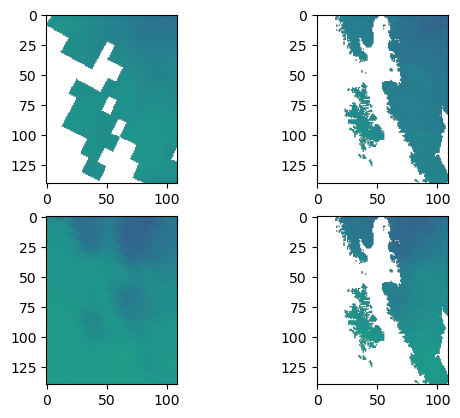

In [15]:
fig, axes= plt.subplots (2,2, dpi=100)

axes[0][0].imshow(mytile.data['cru-input'][1950].dataset['tair_avg'][0], vmin=-50, vmax=50)
axes[0][1].imshow(mytile.data['worldclim'].dataset['tair_avg'][0], vmin=-50, vmax=50)
axes[1][0].imshow(mytile.data['era5-input'][1950].dataset['tair_avg'][0], vmin=-50, vmax=50)
axes[1][1].imshow(mytile.data['era5-corr'][1950].dataset['tair_avg'][0], vmin=-50, vmax=50)

In [16]:
# log.suspend()
# with joblib.parallel_config(backend="loky", n_jobs=24, verbose=20):
#     mytile.save('working/03-tiles-testing-qdm-v2-ready', overwrite=True, clear_existing=True, use_zlib=True, parallel=True)
# log.resume()

In [17]:
from cmethods import adjust
import xarray as xr

In [18]:
# variables = ['tair_avg','prec', 'vapo', 'nirr']
# h_p = mytile.data['cru-input'][1950:]
# # var = 'tair_avg'
# temp = [h_p[yr].dataset[variables ] for yr in h_p.range()]

# simh = xr.concat(temp, dim='time').convert_calendar("noleap")


# p_p = mytile.data['cru-input'][1901:1950]
# temp = [p_p[yr].dataset[variables ] for yr in p_p.range()]
# simp = xr.concat(temp, dim='time').convert_calendar("noleap")

# o_p = mytile.data['era5-corr'][1950:2021]
# temp = [o_p[yr].dataset[variables ] for yr in o_p.range()]
# obsh = xr.concat(temp, dim='time').convert_calendar("noleap")

In [19]:
# tas_result = adjust(
#         method="quantile_delta_mapping",
#         obs=obsh,
#         simh=simh,
#         simp=simp,
#         kind="+",
#         n_quantiles = 1000
#     )

In [25]:
def general_downscale(self, method, variables, hist_period, proj_period, obs_key, sim_key, kind='+', **kwargs ):
    print('building obsh')
    obsh = self.data[obs_key].convert_range_to_single_dataset(variables, hist_period[0], hist_period[1])
    print('building simh')
    simh = self.data[sim_key].convert_range_to_single_dataset(variables, hist_period[0], hist_period[1])
    print('building simp')
    simp = self.data[sim_key].convert_range_to_single_dataset(variables, proj_period[0], proj_period[1])
    results = []
    
    for var in variables:
        print('downscaling', var)
        temp = adjust(
            method=method,
            obs=obsh[var],
            simh=simh[var],
            simp=simp[var],
            kind="+",
            **kwargs
        )[var].transpose('time', 'y','x')
        results.append(temp)
    return xr.merge(results)
    
# n_quantiles = 1000
# "quantile_delta_mapping"
variables = ['tair_avg','prec', 'vapo', 'nirr']
r = general_downscale(mytile, "quantile_delta_mapping", variables, (1950,2020), (1901,1949), 'era5-corr', 'cru-input', n_quantiles = 1000)




building obsh
building simh
building simp
downscaling tair_avg


/home/rwspicer/miniforge3/envs/temds/lib/python3.11/site-packages/cmethods/distribution.py:235: RuntimeWarning: All-NaN slice encountered
  global_max = kwargs.get("global_max", max(np.nanmax(obs), np.nanmax(simh)))
/home/rwspicer/miniforge3/envs/temds/lib/python3.11/site-packages/cmethods/distribution.py:236: RuntimeWarning: All-NaN slice encountered
  global_min = kwargs.get("global_min", min(np.nanmin(obs), np.nanmin(simh)))
/home/rwspicer/miniforge3/envs/temds/lib/python3.11/site-packages/cmethods/utils.py:206: RuntimeWarning: invalid value encountered in divide
  return cdf / cdf[-1]


downscaling prec


/home/rwspicer/miniforge3/envs/temds/lib/python3.11/site-packages/cmethods/distribution.py:235: RuntimeWarning: All-NaN slice encountered
  global_max = kwargs.get("global_max", max(np.nanmax(obs), np.nanmax(simh)))
/home/rwspicer/miniforge3/envs/temds/lib/python3.11/site-packages/cmethods/distribution.py:236: RuntimeWarning: All-NaN slice encountered
  global_min = kwargs.get("global_min", min(np.nanmin(obs), np.nanmin(simh)))
/home/rwspicer/miniforge3/envs/temds/lib/python3.11/site-packages/cmethods/utils.py:206: RuntimeWarning: invalid value encountered in divide
  return cdf / cdf[-1]


downscaling vapo


/home/rwspicer/miniforge3/envs/temds/lib/python3.11/site-packages/cmethods/distribution.py:235: RuntimeWarning: All-NaN slice encountered
  global_max = kwargs.get("global_max", max(np.nanmax(obs), np.nanmax(simh)))
/home/rwspicer/miniforge3/envs/temds/lib/python3.11/site-packages/cmethods/distribution.py:236: RuntimeWarning: All-NaN slice encountered
  global_min = kwargs.get("global_min", min(np.nanmin(obs), np.nanmin(simh)))
/home/rwspicer/miniforge3/envs/temds/lib/python3.11/site-packages/cmethods/utils.py:206: RuntimeWarning: invalid value encountered in divide
  return cdf / cdf[-1]


downscaling nirr


/home/rwspicer/miniforge3/envs/temds/lib/python3.11/site-packages/cmethods/distribution.py:235: RuntimeWarning: All-NaN slice encountered
  global_max = kwargs.get("global_max", max(np.nanmax(obs), np.nanmax(simh)))
/home/rwspicer/miniforge3/envs/temds/lib/python3.11/site-packages/cmethods/distribution.py:236: RuntimeWarning: All-NaN slice encountered
  global_min = kwargs.get("global_min", min(np.nanmin(obs), np.nanmin(simh)))
/home/rwspicer/miniforge3/envs/temds/lib/python3.11/site-packages/cmethods/utils.py:206: RuntimeWarning: invalid value encountered in divide
  return cdf / cdf[-1]


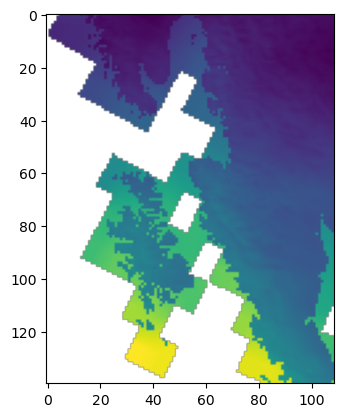

In [28]:
plt.imshow(r.nirr[0])

In [ ]:
tas_result['tair_avg']

In [29]:
r.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=True)
r.rio.write_crs(tile_index.crs, inplace=True)
r.rio.write_coordinate_system(inplace=True) 

<xarray.Dataset> Size: 4GB
Dimensions:      (x: 109, y: 140, time: 17885)
Coordinates:
  * x            (x) float64 872B -1.756e+06 -1.752e+06 ... -1.324e+06
  * y            (y) float64 1kB 2.837e+06 2.841e+06 ... 3.389e+06 3.393e+06
  * time         (time) object 143kB 1901-01-01 00:00:00 ... 1949-12-31 00:00:00
    spatial_ref  int64 8B 0
Data variables:
    tair_avg     (time, y, x) float32 1GB nan nan nan ... -5.45 -5.286 -7.275
    prec         (time, y, x) float32 1GB nan nan nan nan ... 0.855 0.8508 1.444
    vapo         (time, y, x) float32 1GB nan nan nan ... 0.3378 0.3413 0.305
    nirr         (time, y, x) float32 1GB nan nan nan nan ... 15.49 15.64 27.46

In [ ]:
dataset.TEMDataset(r).save('working/03-tiles-testing-qdm-v2-ready/H07_V16/init-ds-result.nc')